In [1]:
from tvb.simulator.lab import *
import numpy as np
from tvb.simulator.backend.dopa_backend import DOPABackend
from tvb.simulator.backend.izimf_backend import IZIMFBackend
from tvb.simulator.backend.nb_mpr import NbMPRBackend
import matplotlib.pyplot as plt

/home/danie/tvb/tvb-root/tvb_library/tvb/datatypes/surfaces.py:60: UserWarning: Geodesic distance module is unavailable; some functionality for surfaces will be unavailable.
  warnings.warn(msg)


In [2]:
# load connectivities
conn_dopamine=np.load("conn_dopamine.npy")
#conn_dopamine=np.zeros((88,88)).astype('float64')
conn_excitator=np.load("conn_excitator.npy")
conn_inhibitor=np.load("conn_inhibitor.npy")
#conn_inhibitor=np.zeros((88,88)).astype('float64')

# configure connectivy for TVB
conn = connectivity.Connectivity()
conn.region_labels = np.array(["L.BSTS", "L.CACG", "L.CMFG", "L.CU", "L.EC", "L.FG", "L.IPG", "L.ITG", "L.ICG","L.LOG", "L.LOFG", "L.LG", "L.MOFG", "L.MTG", "L.PHIG", "L.PaCG", "L.POP", "L.POR","L.PTR", "L.PCAL", "L.PoCG", "L.PCG", "L.PrCG", "L.PCU", "L.RACG", "L.RMFG", "L.SFG",
    "L.SPG", "L.STG", "L.SMG", "L.FP", "L.TP", "L.TTG", "L.IN", "L.CER", "L.TH", "L.CA","L.PU", "L.HI", "L.AC", "lh-GPe", "lh-GPi", "lh-STN", "rh-GPe","rh-GPi", "rh-STN", "R.TH", "R.CA", "R.PU", "R.HI",  "R.AC", "R.BSTS",
    "R.CACG", "R.CMFG", "R.CU", "R.EC", "R.FG", "R.IPG", "R.ITG", "R.ICG", "R.LOG","R.LOFG", "R.LG", "R.MOFG", "R.MTG", "R.PHIG", "R.PaCG", "R.POP", "R.POR", "R.PTR","R.PCAL", "R.PoCG", "R.PCG", "R.PrCG", "R.PCU", "R.RACG", "R.RMFG", "R.SFG", "R.SPG",
    "R.STG", "R.SMG", "R.FP", "R.TP", "R.TTG", "R.IN", "R.CER","SubstantiaNigraLH","SubstantiaNigraRH"])
conn.centres = np.zeros((3,88)) # just some trick to create the object in TVB
conn.weights = conn_excitator # inhibitory and dopamine connectivity has to be introduced later (multiple connectivites not implemented in TVB)
conn.tract_lengths = (conn_excitator*.0+100).astype('i') # another trick, we won't be using delays
conn.configure()

# Gast model

\begin{align}
\begin{split}
& \frac{dr}{dt} = \frac{\Delta k^2 |v - v_r|}{\pi C} + \frac{r}{C} \left( k (2v - v_r - v_t) - g_a S_a - g_g S_g \right) \\
& \frac{dv}{dt} = \frac{1}{C} \Big( k v (v - v_r - v_t) - C \pi r \big( \Delta (v - v_r) + \pi C r / k \big) + k v_r v_t \\
& \quad + g_a S_a (E_r - v) + g_g S_g (E_r - v) + I - u \Big) \\
& \frac{du}{dt} = a \big( b (v - v_r) - u \big) + d r \\
& \frac{dS_a}{dt} = -\frac{S_a}{\tau_{S_a}} + S_{ja} (r + c_{exc}) \\
& \frac{dS_g}{dt} = -\frac{S_g}{\tau_{S_g}} + S_{jg} c_{inh} \\
& \frac{dD_p}{dt} = \frac{k c_{dopa} - V_{max} D_p}{\tau_{D_p} (K_m + D_p)} \\
& \frac{dM_d}{dt} = \frac{-M_d + \frac{R_d}{1 + e^{S_d (D_p + Z)}}}{\tau_{M_d}}
\end{split}
\end{align}



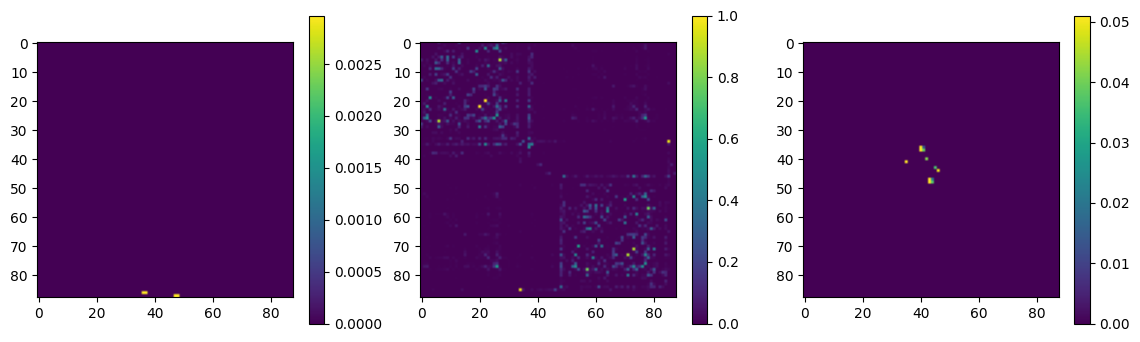

In [3]:
fig, (ax, ax2, ax3) = plt.subplots(1, 3, figsize=(14,5))
im = ax.imshow(conn_dopamine, vmax=conn_dopamine.max()/10)
plt.colorbar(im, shrink=.8, ax=ax)
im2 = ax2.imshow(conn_excitator)
plt.colorbar(im2, shrink=.8, ax=ax2)
im3 = ax3.imshow(conn_inhibitor, vmax=conn_inhibitor.max()/10)
plt.colorbar(im3, shrink=.8, ax=ax3)
plt.show()

The middle one is the one we know. \
The left one are the dopamine connections from the substatia nigra to...?\
The right one are inhibitory connections from ... to ? \
You can look for the answer.

# Let's run a simuation with some starting parameters :

In [4]:

# Now we have 3 coupling factors :
g_dopa, g_excit, g_inhib = np.array([9e-1]), 7e-2, np.array([1.7e-2])

nsigma = 0.01
n_nodes = 88
r0, V0, u0, sa0, sg0, Dp0, Md0 = 0.2, -60.0, 0.0, 0.0, 0.0, 0.0, 0.0
init_cond = np.array([r0, V0, u0, sa0, sg0, Dp0, Md0])
initial_cond = np.repeat(init_cond, n_nodes).reshape((1, 7, 88, 1))
r0s = np.random.uniform(high=1., low=0., size=(1, 1, 88, 1))
v0s = np.random.uniform(high=-50., low=-100., size=(1, 1, 88, 1))
initial_cond[:,:1,:,:] = r0s
initial_cond[:,1:2,:,:] = v0s

In [5]:
izm = models.IziMF(C=np.array([100.0]), k=np.array([0.7]), Delta=np.array([0.5]), v_r=np.array([-60.0]), v_t=np.array([-40.0]), ga=np.array([1.0]), E_r=np.array([0.0]), I=np.array([50.0]), 
     kappa=np.array([100.0]), tausa=np.array([6.0]), sja=np.array([15.0]))

In [6]:
izm??

Type:           IziMF
String form:   
IziMF (
  C ....................... 100.0
  Delta ................... 0.5
  E_r ..................... 0.0
  I ....................... 50.0
  Km ...................... 150.0
  Rd ...................... 1.0
  Sd ...................... -1.0
  Type .................... IziMF
  Vmax .................... 1300.0
  Z ....................... 1.0
  a ....................... 0.03
  b ....................... -2.0
  coupling_terms .......... ['Coupling_Term_r', 'Coupling_Term_v', 'Coupling_Term_u', 'Coupling_Term_sa', 'Coupling_term_sg', 'Coupling_term_Dp', 'Coupling_term_Md']
  eta ..................... 10.0
  ga ...................... 1.0
  gg ...................... 15.0
  gid ..................... UUID('945e7222-00d1-42ba-8a5a-a53a5613f1a7')
  k ....................... 0.7
  kappa ................... 100.0
  parameter_names ......... ['Delta', 'eta', 'C', 'k', 'v_r', 'v_t', 'ga', 'gg', 'E_r', 'b', 'a', 'kappa', 'tausa', 'tausg', 'sja', 'sjg', 'I', 'Vmax', 'K

In [7]:
sim = simulator.Simulator(
    model=izm,
    connectivity=conn,
    coupling=coupling.Linear(
        a=np.array([g_excit])
    ),
    conduction_speed=1.,
            integrator=integrators.HeunStochastic(
            dt=0.1,
            noise=noise.Additive(
                nsig=np.array(
                    [nsigma,nsigma*10,nsigma/5,nsigma/10,nsigma/5,nsigma/3,nsigma*5]
                ), 
                noise_seed=42)
        ),
    monitors=[monitors.Raw()],
    initial_conditions=initial_cond
).configure()

In [8]:
izimf_backed = IZIMFBackend()

In [9]:
(t, tavg), c = izimf_backed.run_sim(sim, conn_inhibitor, conn_dopamine, g_inhib, g_dopa, simulation_length=10000)


(0.5, 10.0, 100.0, 0.7, -60.0, -40.0, 1.0, 15.0, 0.0, -2.0, 0.03, 100.0, 6.0, 6.0, 15.0, 15.0, 50.0, 1300.0, 150.0, 500.0, 1.0, -1.0, 1.0, 500.0)


/home/danie/tvb/tvb-root/tvb_library/tvb/simulator/backend/izimf_backend.py:136: NumbaPerformanceWarning: '@' is faster on contiguous arrays, called on (Array(float64, 2, 'F', False, aligned=True), Array(float64, 1, 'A', False, aligned=True))
  coupling = cx(X, connectivities, g_i, g_e, g_d)


In [10]:
tavg[0].shape
arr = np.array(tavg)

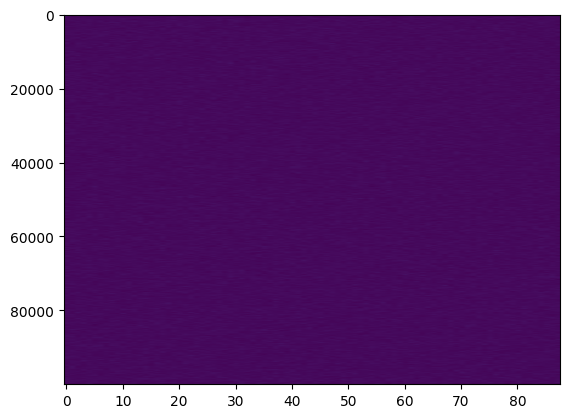

In [11]:
plt.imshow(arr[:,0,:], aspect='auto', vmax=2)

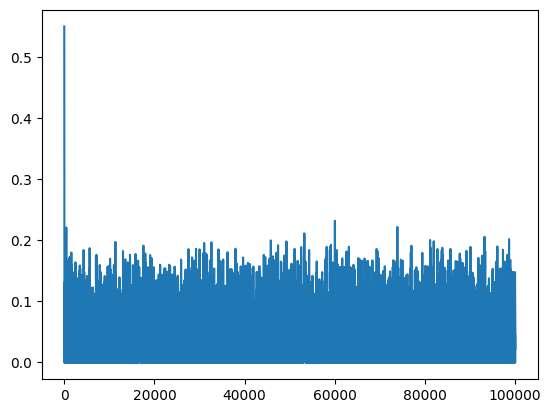

In [12]:
plt.plot(arr[:,0,0])

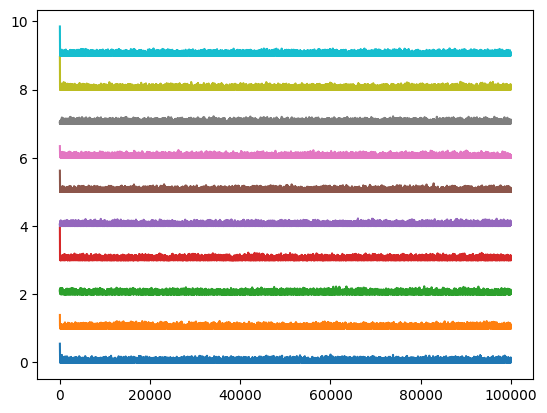

In [13]:
plt.plot(np.arange(10) + arr[:,0,:10])
plt.show()

In [14]:
del sim

In [15]:
g_dopa, g_excit, g_inhib = np.array([1.4e-1]), 7e-2, np.array([1.7e-2])
sim = simulator.Simulator(
    model=izm,
    connectivity=conn,
    coupling=coupling.Linear(
        a=np.array([g_excit])
    ),
    conduction_speed=1.,
            integrator=integrators.HeunStochastic(
            dt=0.01,
            noise=noise.Additive(
                nsig=np.array(
                    [nsigma,nsigma*10,nsigma/10,nsigma/10, nsigma/10,nsigma/10, nsigma/10]
                ), 
                noise_seed=42)
        ),
    monitors=[monitors.Raw()],
    initial_conditions=initial_cond
).configure()


In [16]:
(t, tavg),_ = izimf_backed.run_sim(sim, conn_inhibitor, conn_dopamine, g_inhib, g_dopa, simulation_length=10000)

(0.5, 10.0, 100.0, 0.7, -60.0, -40.0, 1.0, 15.0, 0.0, -2.0, 0.03, 100.0, 6.0, 6.0, 15.0, 15.0, 50.0, 1300.0, 150.0, 500.0, 1.0, -1.0, 1.0, 500.0)


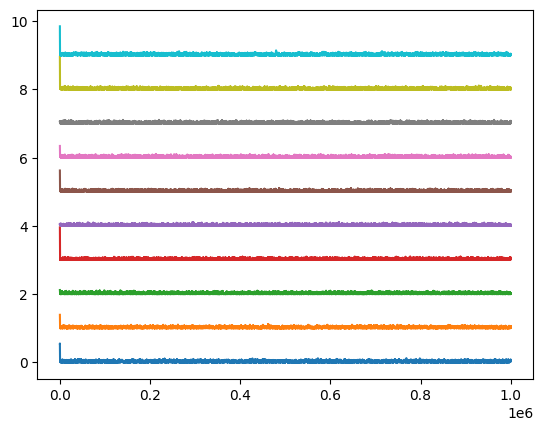

: 

In [ ]:
plt.plot(np.arange(10) + tavg[:,0,:10])
plt.show()